In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("server_infrastructure_performance_5000.csv")
df

,Server_ID,Timestamp,Server_Type,Operating_System,CPU_Usage,Memory_Usage,Disk_Usage,Disk_IO,Network_In_Mbps,Network_Out_Mbps,...,Response_Time_ms,Active_Connections,Request_Count,Error_Count,Process_Count,Uptime_Hours,Temperature_C,Day_of_Week,Hour,Performance_Issue
0,SRV-097,01-01-2026 01:30,Database,Linux,64.80,69.63,58.54,58.46,1441.77,1010.41,...,370.22,661,7284,15,246,652.11,59.83,Thursday,1,0
1,SRV-013,01-01-2026 02:30,Application,Linux,49.27,47.69,65.46,63.03,1211.31,1021.13,...,219.61,454,6787,7,165,1454.45,51.17,Thursday,2,0
2,SRV-041,01-01-2026 03:30,Database,Linux,60.88,41.95,51.33,64.58,1509.37,1220.39,...,304.11,660,7507,8,281,1263.60,54.77,Thursday,3,0
3,SRV-073,01-01-2026 04:00,API,Linux,59.67,53.88,52.92,89.80,1489.91,1082.84,...,280.13,684,7170,8,274,606.29,58.92,Thursday,4,0
4,SRV-025,01-01-2026 04:00,File,Linux,62.16,40.06,43.66,40.24,1263.97,875.24,...,233.30,840,5989,7,203,924.44,55.36,Thursday,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SRV-066,30-06-2026 21:00,Application,Linux,73.43,48.58,39.90,43.24,1148.74,1047.98,...,266.60,832,6830,10,286,1460.55,55.87,Tuesday,21,0
4996,SRV-065,30-06-2026 21:30,Application,Linux,81.96,46.60,58.86,74.94,1269.98,1077.80,...,320.39,606,6967,12,261,718.20,58.54,Tuesday,21,0
4997,SRV-008,30-06-2026 22:30,File,Linux,55.73,55.59,63.84,86.27,1200.17,828.20,...,260.36,310,5826,11,255,568.32,61.09,Tuesday,22,0
4998,SRV-025,30-06-2026 23:00,File,Linux,81.53,82.84,41.53,41.81,1081.89,681.87,...,319.20,504,5826,14,281,736.42,60.75,Tuesday,23,0


In [3]:
df.isnull().sum()

Server_ID              0
Timestamp              0
Server_Type            0
Operating_System       0
CPU_Usage              0
Memory_Usage           0
Disk_Usage             0
Disk_IO                0
Network_In_Mbps        0
Network_Out_Mbps       0
Network_Latency_ms    50
Response_Time_ms      50
Active_Connections     0
Request_Count          0
Error_Count            0
Process_Count          0
Uptime_Hours           0
Temperature_C         50
Day_of_Week            0
Hour                   0
Performance_Issue      0
dtype: int64

In [4]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [5]:
df.isnull().sum()

Server_ID             0
Timestamp             0
Server_Type           0
Operating_System      0
CPU_Usage             0
Memory_Usage          0
Disk_Usage            0
Disk_IO               0
Network_In_Mbps       0
Network_Out_Mbps      0
Network_Latency_ms    0
Response_Time_ms      0
Active_Connections    0
Request_Count         0
Error_Count           0
Process_Count         0
Uptime_Hours          0
Temperature_C         0
Day_of_Week           0
Hour                  0
Performance_Issue     0
dtype: int64

In [6]:
df=df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(5000, 21)

In [9]:
#target

In [10]:
df["Performance_Issue"].value_counts()

Performance_Issue
0    4879
1     121
Name: count, dtype: int64

In [11]:
#performance related features

In [12]:
features = [
    "Server_Type",
    "Operating_System",
    "CPU_Usage",
    "Memory_Usage",
    "Disk_Usage",
    "Disk_IO",
    "Network_In_Mbps",
    "Network_Out_Mbps",
    "Network_Latency_ms",
    "Response_Time_ms",
    "Active_Connections",
    "Request_Count",
    "Error_Count",
    "Process_Count",
    "Uptime_Hours",
    "Temperature_C",
    "Hour"
]

In [13]:
X = df[features]
y = df["Performance_Issue"]

In [14]:
#convert categorical col to numbers

In [15]:
X = pd.get_dummies(X,columns=["Server_Type", "Operating_System"],drop_first=True)

In [16]:
X.head()

,CPU_Usage,Memory_Usage,Disk_Usage,Disk_IO,Network_In_Mbps,Network_Out_Mbps,Network_Latency_ms,Response_Time_ms,Active_Connections,Request_Count,Error_Count,Process_Count,Uptime_Hours,Temperature_C,Hour,Server_Type_Application,Server_Type_Database,Server_Type_File,Server_Type_Web,Operating_System_Windows Server
0,64.80,69.63,58.54,58.46,1441.77,1010.41,24.91,370.22,661,7284,15,246,652.11,59.83,1,False,True,False,False,False
1,49.27,47.69,65.46,63.03,1211.31,1021.13,25.44,219.61,454,6787,7,165,1454.45,51.17,2,True,False,False,False,False
2,60.88,41.95,51.33,64.58,1509.37,1220.39,25.10,304.11,660,7507,8,281,1263.60,54.77,3,False,True,False,False,False
3,59.67,53.88,52.92,89.80,1489.91,1082.84,27.97,280.13,684,7170,8,274,606.29,58.92,4,False,False,False,False,False
4,62.16,40.06,43.66,40.24,1263.97,875.24,12.90,233.30,840,5989,7,203,924.44,55.36,4,False,False,True,False,False


In [17]:
#split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [19]:
#Logistic Regression

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

C:\Users\NITHYA\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
#Decision tree
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [21]:
#Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [22]:
#XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [30]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [25]:
#imbalanced target
cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean F1 Score": scores.mean(),
        "Standard Deviation": scores.std()
    })

C:\Users\NITHYA\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\NITHYA\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

In [26]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score

In [27]:
#Compare the models
def evaluate_model(name, y_test, prediction):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction, zero_division=0),
        "Recall": recall_score(y_test, prediction, zero_division=0),
        "F1 Score": f1_score(y_test, prediction, zero_division=0)
    }

In [28]:
results = []

results.append(
    evaluate_model("Logistic Regression", y_test, lr_pred)
)

results.append(
    evaluate_model("Decision Tree", y_test, dt_pred)
)

results.append(
    evaluate_model("Random Forest", y_test, rf_pred)
)

results.append(
    evaluate_model("XGBoost", y_test, xgb_pred)
)

In [29]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.845,0.125714,0.916667,0.221106
1,Decision Tree,0.971,0.407407,0.458333,0.431373
2,Random Forest,0.983,1.000000,0.291667,0.451613
3,XGBoost,0.988,0.800000,0.666667,0.727273


In [31]:
#train all models
for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

C:\Users\NITHYA\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
#make predictions
lr_pred = lr.predict(X_test)

dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

xgb_pred = xgb.predict(X_test)

In [33]:
#creating evaluation metrc
def evaluate_model(name, y_test, prediction):

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Precision": precision_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            prediction,
            zero_division=0
        )
    }

In [34]:
#compare all models
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

In [35]:
#final comparison
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.845,0.125714,0.916667,0.221106
1,Decision Tree,0.971,0.407407,0.458333,0.431373
2,Random Forest,0.983,1.000000,0.291667,0.451613
3,XGBoost,0.988,0.800000,0.666667,0.727273


In [36]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.988,0.800000,0.666667,0.727273
2,Random Forest,0.983,1.000000,0.291667,0.451613
1,Decision Tree,0.971,0.407407,0.458333,0.431373
0,Logistic Regression,0.845,0.125714,0.916667,0.221106


In [38]:
#confusion metrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(cm)

[[972   4]
 [  8  16]]


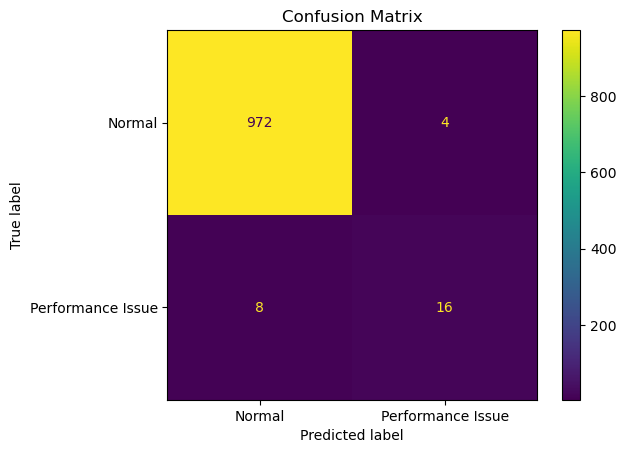

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=[
        "Normal",
        "Performance Issue"
    ]
)

plt.title("Confusion Matrix")
plt.show()

In [41]:
#classification report
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "Normal",
            "Performance Issue"
        ]
    )
)

                   precision    recall  f1-score   support

           Normal       0.99      1.00      0.99       976
Performance Issue       0.80      0.67      0.73        24

         accuracy                           0.99      1000
        macro avg       0.90      0.83      0.86      1000
     weighted avg       0.99      0.99      0.99      1000



In [42]:
#feature importance
importance = xgb.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

In [43]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [44]:
feature_importance.head(10)

,Feature,Importance
7,Response_Time_ms,0.326759
0,CPU_Usage,0.146543
5,Network_Out_Mbps,0.102266
3,Disk_IO,0.073903
1,Memory_Usage,0.061959
10,Error_Count,0.042378
4,Network_In_Mbps,0.032304
19,Operating_System_Windows Server,0.027917
11,Process_Count,0.022386
2,Disk_Usage,0.021675


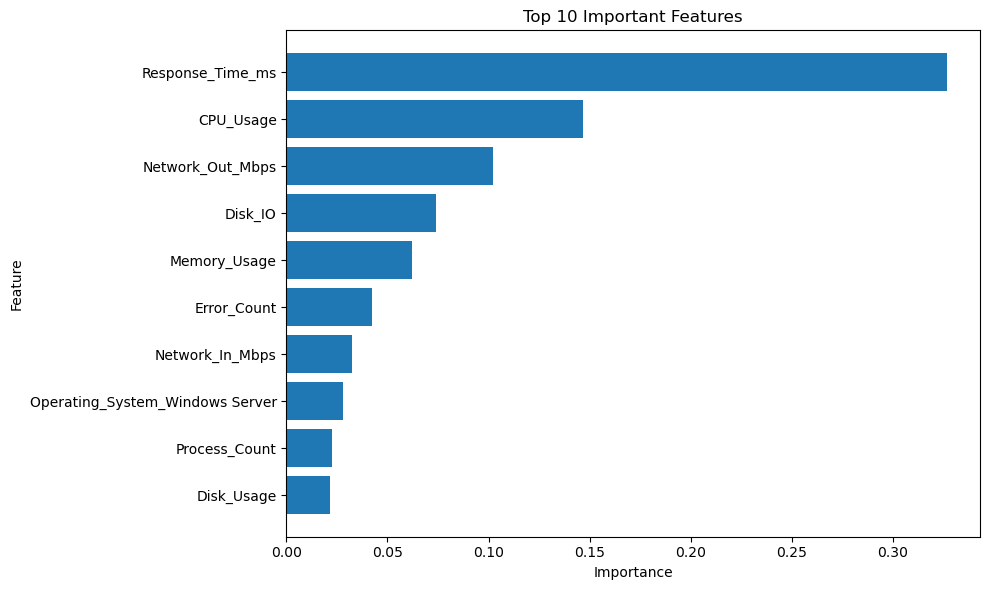

In [45]:
#to show chart
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.tight_layout()

plt.show()

In [50]:
#to [redict a new server
new_server = pd.DataFrame({
    "Server_Type": ["Web"],
    "Operating_System": ["Linux"],
    "CPU_Usage": [91],
    "Memory_Usage": [88],
    "Disk_Usage": [75],
    "Disk_IO": [82],
    "Network_In_Mbps": [1800],
    "Network_Out_Mbps": [1400],
    "Network_Latency_ms": [65],
    "Response_Time_ms": [720],
    "Active_Connections": [1200],
    "Request_Count": [10000],
    "Error_Count": [40],
    "Process_Count": [300],
    "Uptime_Hours": [900],
    "Temperature_C": [76],
    "Hour": [14]
})

In [51]:
new_server = pd.get_dummies(
    new_server,
    columns=[
        "Server_Type",
        "Operating_System"
    ],
    drop_first=True
)
new_server = new_server.reindex(
    columns=X.columns,
    fill_value=0
)
prediction = xgb.predict(new_server)
if prediction[0] == 1:
    print("Predicted Status: Performance Issue")
else:
    print("Predicted Status: Normal")

Predicted Status: Performance Issue


In [52]:
df.to_csv("Server_performance_results.csv",index=False)

In [53]:
feature_importance.to_csv(
    "server_feature_importance.csv",
    index=False
)